# AI Study Planner

In [2]:
import sys
print(sys.executable)

c:\Users\eeshu\Desktop\AI Study Planner\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression # Added this import

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eeshu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eeshu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Step 2: Load Dataset

In [4]:
df = pd.read_csv("dataset/AI_Study_Planner_Dataset.csv")
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,productivity_score,exam_score,subject,difficulty_level,preparation_level,exam_date,days_left,available_hours_per_day,priority_score,recommended_study_hours
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,73.65,50.16,Mathematics,5,3,2026-08-12,27,10.0,9.11,9.25
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,13.70,1.00,DBMS,3,1,2026-08-24,39,10.0,8.77,7.71
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,45.15,18.30,Python,2,2,2026-08-25,40,10.0,6.75,6.32
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,20.92,9.37,DBMS,3,1,2026-07-31,15,10.0,10.00,9.12
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,59.23,27.81,Statistics,4,2,2026-09-25,71,10.0,8.42,8.34


In [5]:
print("Data Information: ",df.info())
print("Data Shape: ",df.shape)
print("Data Columns: ",df.columns)
print("Data Columns: ",df.isnull().sum())
print("Remove and Calculate Data Duplicates Values: ",df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               5000 non-null   int64  
 1   age                      5000 non-null   int64  
 2   gender                   5000 non-null   object 
 3   academic_level           5000 non-null   object 
 4   study_hours              5000 non-null   float64
 5   self_study_hours         5000 non-null   float64
 6   online_classes_hours     5000 non-null   float64
 7   social_media_hours       5000 non-null   float64
 8   gaming_hours             5000 non-null   float64
 9   sleep_hours              5000 non-null   float64
 10  screen_time_hours        5000 non-null   float64
 11  exercise_minutes         5000 non-null   int64  
 12  caffeine_intake_mg       5000 non-null   int64  
 13  part_time_job            5000 non-null   int64  
 14  upcoming_deadline       

In [6]:
# -------------------------------
# Data Preprocessing
# -------------------------------

print("Missing Values:")
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
print("\nDataset Shape:", df.shape)
display(df.head())

Missing Values:
student_id                 0
age                        0
gender                     0
academic_level             0
study_hours                0
self_study_hours           0
online_classes_hours       0
social_media_hours         0
gaming_hours               0
sleep_hours                0
screen_time_hours          0
exercise_minutes           0
caffeine_intake_mg         0
part_time_job              0
upcoming_deadline          0
internet_quality           0
mental_health_score        0
focus_index                0
burnout_level              0
productivity_score         0
exam_score                 0
subject                    0
difficulty_level           0
preparation_level          0
exam_date                  0
days_left                  0
available_hours_per_day    0
priority_score             0
recommended_study_hours    0
dtype: int64

Dataset Shape: (5000, 29)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,productivity_score,exam_score,subject,difficulty_level,preparation_level,exam_date,days_left,available_hours_per_day,priority_score,recommended_study_hours
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,73.65,50.16,Mathematics,5,3,2026-08-12,27,10.0,9.11,9.25
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,13.70,1.00,DBMS,3,1,2026-08-24,39,10.0,8.77,7.71
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,45.15,18.30,Python,2,2,2026-08-25,40,10.0,6.75,6.32
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,20.92,9.37,DBMS,3,1,2026-07-31,15,10.0,10.00,9.12
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,59.23,27.81,Statistics,4,2,2026-09-25,71,10.0,8.42,8.34


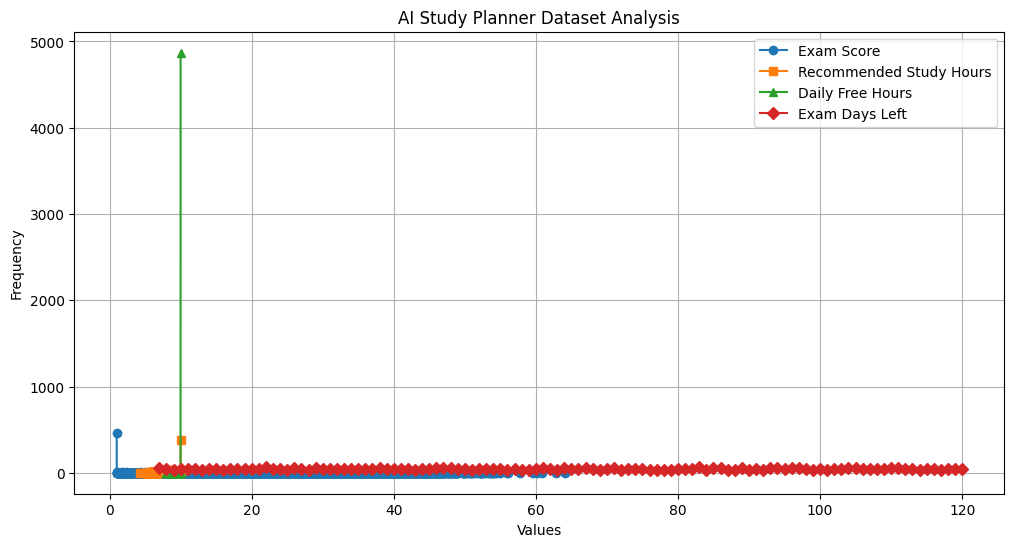

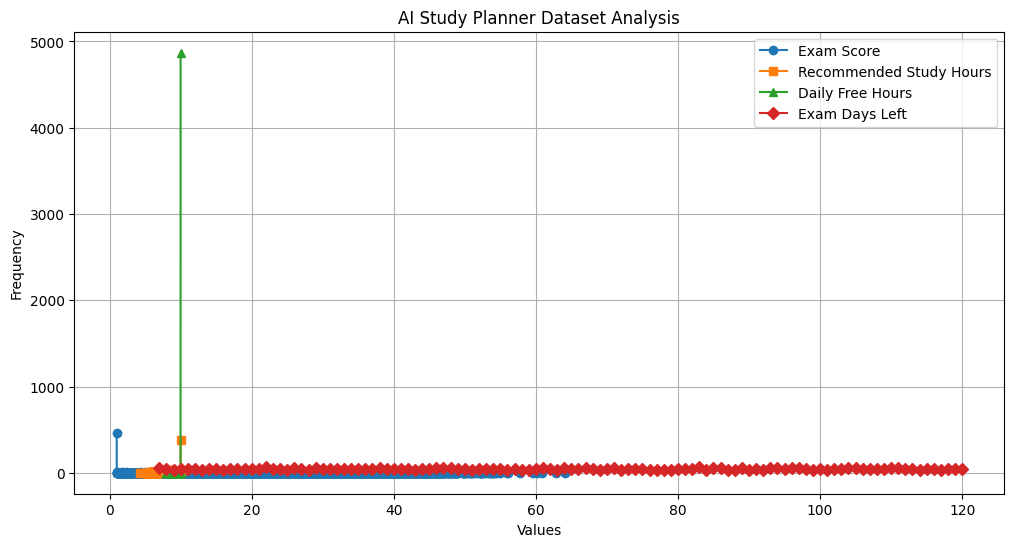

In [8]:
plt.figure(figsize=(12,6))

# Exam Score (was 'Current_Marks')
exam_scores = df['exam_score'].value_counts().sort_index()
plt.plot(exam_scores.index, exam_scores.values, marker='o', label='Exam Score')

# Recommended Study Hours (was 'Study_Hours_Required')
recommended_study_hours = df['recommended_study_hours'].value_counts().sort_index()
plt.plot(recommended_study_hours.index, recommended_study_hours.values, marker='s', label='Recommended Study Hours')

# Daily Free Hours
free_hours = df['available_hours_per_day'].value_counts().sort_index() # Using 'available_hours_per_day' as 'Daily_Free_Hours' was not found either
plt.plot(free_hours.index, free_hours.values, marker='^', label='Daily Free Hours')

# Exam Days Left
exam_days = df['days_left'].value_counts().sort_index() # Using 'days_left' as 'Exam_Days_Left' was not found either
plt.plot(exam_days.index, exam_days.values, marker='D', label='Exam Days Left')

plt.title("AI Study Planner Dataset Analysis")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

display(plt.gcf()) # Use display(plt.gcf()) for Colab

In [9]:
# 1. Create separate encoders so they don't overwrite each other
le_subject = LabelEncoder()
le_academic = LabelEncoder()

# 2. Fit and transform each column individually
df['subject'] = le_subject.fit_transform(df['subject'])
df['academic_level'] = le_academic.fit_transform(df['academic_level'])

# Note: difficulty_level is already numbers (1, 2, 3...) in your data,
# so we don't need to encode it at all!

'''le = LabelEncoder()

# Store the original dataframe before encoding to help with inverse transforms later
df_original = df.copy()

df['subject'] = le.fit_transform(df['subject'])
df['academic_level'] = le.fit_transform(df['academic_level'])
df['difficulty_level'] = le.fit_transform(df['difficulty_level'])

# Removing 'Clean_Text' encoding as 'Goal_Text' does not exist.
display(df.head())'''

"le = LabelEncoder()\n\n# Store the original dataframe before encoding to help with inverse transforms later\ndf_original = df.copy()\n\ndf['subject'] = le.fit_transform(df['subject'])\ndf['academic_level'] = le.fit_transform(df['academic_level'])\ndf['difficulty_level'] = le.fit_transform(df['difficulty_level'])\n\n# Removing 'Clean_Text' encoding as 'Goal_Text' does not exist.\ndisplay(df.head())"

In [10]:
X = df[['subject',
        'academic_level', # Added academic_level to features
        'exam_score',
        'days_left',
        'available_hours_per_day',
        'difficulty_level']]

y = df['recommended_study_hours']
print("Input Features:")
display(X.head())

print("\nTarget Variable:")
display(y.head())

Input Features:


,subject,academic_level,exam_score,days_left,available_hours_per_day,difficulty_level
0,6,0,50.16,27,10.0,5
1,2,0,1.00,39,10.0,3
2,8,0,18.30,40,10.0,2
3,2,0,9.37,15,10.0,3
4,9,0,27.81,71,10.0,4



Target Variable:


0    9.25
1    7.71
2    6.32
3    9.12
4    8.34
Name: recommended_study_hours, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape :", x_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape :", y_test.shape)

Training Data Shape: (4000, 6)
Testing Data Shape : (1000, 6)
Training Target Shape: (4000,)
Testing Target Shape : (1000,)


In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)
print("Random Forest Model Trained Successfully!")
import joblib

joblib.dump(model, "study_planner_model.pkl")

print("Model Saved Successfully")

Random Forest Model Trained Successfully!
Model Saved Successfully


In [13]:
y_pred = model.predict(x_test)

print("Predicted Study Hours:")
print(y_pred[:10])

Predicted Study Hours:
[8.954  8.431  6.5026 8.9906 7.9131 9.931  8.2457 9.7743 6.3438 8.3025]


In [14]:
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

result.head(10)

,Actual,Predicted
0,9.14,8.9540
1,8.10,8.4310
2,6.21,6.5026
3,8.82,8.9906
4,8.07,7.9131
5,10.00,9.9310
6,8.19,8.2457
7,9.34,9.7743
8,5.72,6.3438
9,8.38,8.3025


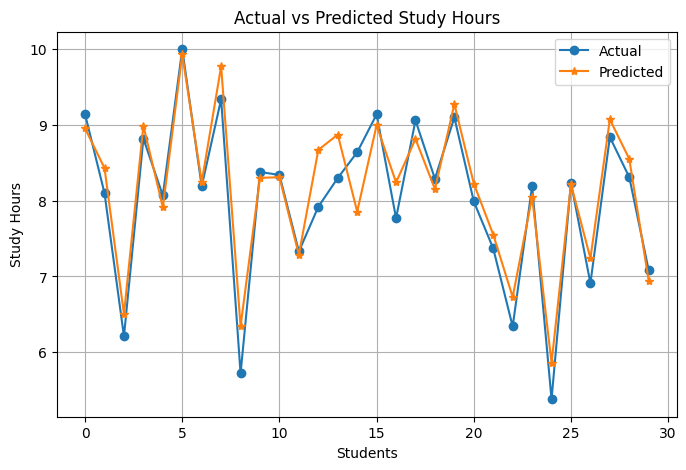

In [15]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:30], label='Actual', marker='o')
plt.plot(y_pred[:30], label='Predicted', marker='*')

plt.title("Actual vs Predicted Study Hours")
plt.xlabel("Students")
plt.ylabel("Study Hours")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Evaluation Results")
print("------------------------")
print("R2 Score :", round(r2, 2))
print("MAE      :", round(mae, 2))
print("MSE      :", round(mse, 2))
print("RMSE     :", round(rmse, 2))

Model Evaluation Results
------------------------
R2 Score : 0.89
MAE      : 0.28
MSE      : 0.12
RMSE     : 0.35


In [ ]:
import pandas as pd

# 1. Print the available options for the user to see
print("--- Available Academic Levels ---")
print(list(le_academic.classes_))
print("\n--- Available Subjects ---")
print(list(le_subject.classes_))
print("-" * 35 + "\n")

# 2. Get raw inputs from the user
user_subject = input("Enter Subject from the list above: ")
user_academic = input("Enter Academic Level from the list above: ")
user_exam_score = float(input("Enter Current Exam Score: "))
user_days_left = int(input("Enter Days Left for Exam: "))
user_free_hours = float(input("Enter Available Free Hours Per Day: "))
user_difficulty = int(input("Enter Difficulty Level (1 to 5): "))

# 3. Directly convert the text using the correct encoder
encoded_subject = le_subject.transform([user_subject])[0]
encoded_academic = le_academic.transform([user_academic])[0]

# 4. Put it into the exact format your model expects
user_data = pd.DataFrame([{
    'subject': encoded_subject,
    'academic_level': encoded_academic,
    'exam_score': user_exam_score,
    'days_left': user_days_left,
    'available_hours_per_day': user_free_hours,
    'difficulty_level': user_difficulty
}])

# 5. Predict using the model
predicted_hours = model.predict(user_data)[0]

# 6. Calculate the 50/10 rule breaks (10 mins break for every 50 mins study = 20% extra time)
total_time_needed = predicted_hours * 1.20
break_time = total_time_needed - predicted_hours

# 7. Print the realistic, sanity-saving schedule
print("\n" + "="*35)
print("       REALISTIC STUDY PLAN       ")
print("="*35)
print(f"Pure Study Time Needed : {predicted_hours:.2f} hours")
print(f"Recommended Break Time : {break_time:.2f} hours (10 mins every 50 mins)")
print(f"Total Time to Block Out: {total_time_needed:.2f} hours")
print("="*35)

--- Available Academic Levels ---
['High School', 'Postgraduate', 'Undergraduate']

--- Available Subjects ---
['Artificial Intelligence', 'Computer Networks', 'DBMS', 'Data Structures', 'Java', 'Machine Learning', 'Mathematics', 'Operating Systems', 'Python', 'Statistics']
-----------------------------------

